# Model 1: Road Closure Probability Prediction

**Objective**: Predict the probability (0-100%) of road closure for traffic events in Bengaluru

**Dataset**: Feature-engineered Astram event data (~8,200 events)

**Approach**:
- Binary classification with probabilistic output
- Calibrated probabilities for reliable risk assessment
- Train models independently (LightGBM, XGBoost, CatBoost)
- Manual single-model selection for tuning and downstream processing
- Threshold optimization for operational decision-making

## 1. Import Libraries

In [ ]:
# Core libraries
import re
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve,
    confusion_matrix, classification_report,
    brier_score_loss, accuracy_score,
    precision_score, recall_score, f1_score
)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import StratifiedKFold

# SMOTE for minority oversampling (fallback to random oversampling)
try:
    from imblearn.over_sampling import SMOTE
    HAS_SMOTE = True
except ImportError:
    from sklearn.utils import resample
    HAS_SMOTE = False
    print("imblearn not found; will use random oversampling as fallback")

# Gradient Boosting Models
import lightgbm as lgb
import xgboost as xgb

# Hyperparameter optimization
import optuna
# Explainability
import shap

# Utilities
from datetime import datetime
import joblib
import os
from pathlib import Path

print("All libraries imported successfully!")
print(f"Python environment ready - {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"SMOTE available: {HAS_SMOTE}")

All libraries imported successfully!
Python environment ready - 2026-06-20 19:23:19


## 2. Load Feature-Engineered Dataset

In [100]:
# Load feature engineered datasets from local workspace
import os
# Dataset paths for Model 1 (road closure) and Model 2 handoff (duration)
ROAD_CLOSURE_DATA_PATH = (r'D:\Python\Gridlock\Phase 2\theme 2\outputs'r'\feature_engineering_v1\road_closure_features_v1.csv')
DURATION_BASE_DATA_PATH = (r'D:\Python\Gridlock\Phase 2\theme 2\outputs'r'\feature_engineering_v1\duration_base_features_v1.csv')

# Keep model artifacts in the project output tree, independent of notebook cwd.
project_outputs_dir = Path(ROAD_CLOSURE_DATA_PATH).resolve().parents[1]
output_dir = str(project_outputs_dir / 'model_road_closure')
os.makedirs(output_dir, exist_ok=True)
print(f"Output directory: {output_dir}")

# Target column names
ROAD_CLOSURE_TARGET = 'target_road_closure'
RANDOM_STATE = 42

# Road-closure data is mandatory
if not os.path.exists(ROAD_CLOSURE_DATA_PATH):
    raise FileNotFoundError(
        f"Missing required file: {ROAD_CLOSURE_DATA_PATH}. "
        f"Current directory: {os.getcwd()}"
    )

road_closure_df = pd.read_csv(ROAD_CLOSURE_DATA_PATH)

print('Road-closure training data:', road_closure_df.shape)
# Backward compatibility for downstream cells that currently use `df`
df = road_closure_df.copy()
print(f"Active training dataframe set: {df.shape}")

Output directory: D:\Python\Gridlock\Phase 2\theme 2\outputs\model_road_closure
Road-closure training data: (8173, 96)
Active training dataframe set: (8173, 96)


## 3. Leakage Audit

This section verifies that blocked post-event fields have not entered the Model 1 input. Statistical checks use only the chronological training portion and produce warnings rather than automatically removing valid predictive features.

In [101]:
METADATA_COLS = [
    'id',
    '_source_row',
    'prediction_datetime',
    'start_datetime',
]

BLOCKED_FEATURES = {
    'requires_road_closure',
    'target_road_closure_missing',
    'duration_minutes_raw',
    'duration_band',
    'duration_source',
    'duration_label_available_at',
    'has_duration_label',
    'end_datetime',
    'closed_datetime',
    'resolved_datetime',
    'modified_datetime',
    'status',
    'closed_by_id',
    'resolved_by_id',
    'last_modified_by_id',
    'comment',
    'endlatitude',
    'endlongitude',
    'end_address',
    'route_path',
    'route_distance_km',
    'has_route_span',
    'has_end_location',
    'end_point_missing_or_zero',
    'resolved_at_address',
    'resolved_at_latitude',
    'resolved_at_longitude',
}

raw_feature_cols = [
    col for col in road_closure_df.columns
    if col not in METADATA_COLS + [ROAD_CLOSURE_TARGET]
]

# Hard leakage checks
blocked_present = sorted(
    set(raw_feature_cols).intersection(BLOCKED_FEATURES)
)

qa_columns_present = sorted(
    col for col in raw_feature_cols
    if col.startswith('qa_')
)

if blocked_present:
    display(pd.DataFrame([{
        'check': 'blocked features absent',
        'status': 'FAIL',
        'observed': blocked_present,
    }]))
    raise ValueError(
        f'Blocked features found: {blocked_present}'
    )

if qa_columns_present:
    display(pd.DataFrame([{
        'check': 'QA-only columns absent',
        'status': 'FAIL',
        'observed': qa_columns_present,
    }]))
    raise ValueError(
        f'QA-only columns found: {qa_columns_present}'
    )

prediction_times = pd.to_datetime(
    road_closure_df['prediction_datetime'],
    errors='coerce',
    utc=True,
)

if not prediction_times.dropna().is_monotonic_increasing:
    display(pd.DataFrame([{
        'check': 'chronological prediction order',
        'status': 'FAIL',
        'observed': 'prediction_datetime is not monotonic',
    }]))
    raise ValueError(
        'Dataset is not ordered by prediction time.'
    )

print('Hard leakage and schema checks passed.')

# Statistical diagnostics: training portion only
audit_train_end = int(0.70 * len(road_closure_df))
audit_train = road_closure_df.iloc[:audit_train_end]
audit_target = audit_train[ROAD_CLOSURE_TARGET].astype(int)

audit_rows = []

for col in raw_feature_cols:
    if not pd.api.types.is_numeric_dtype(audit_train[col]):
        continue

    values = pd.to_numeric(
        audit_train[col], errors='coerce'
    ).replace([np.inf, -np.inf], np.nan)

    valid = values.notna() & audit_target.notna()

    if (
        valid.sum() == 0
        or values.loc[valid].nunique() <= 1
        or audit_target.loc[valid].nunique() != 2
    ):
        continue

    x_valid = values.loc[valid]
    y_valid = audit_target.loc[valid]

    correlation = x_valid.corr(y_valid)
    auc = roc_auc_score(y_valid, x_valid)
    auc_strength = max(auc, 1 - auc)

    suspicious = (
        auc_strength >= 0.995
        or (
            pd.notna(correlation)
            and abs(correlation) >= 0.98
        )
    )

    audit_rows.append({
        'feature': col,
        'auc_strength': auc_strength,
        'correlation': correlation,
        'status': 'WARN' if suspicious else 'PASS',
        'decision': (
            'manual_review_only'
            if suspicious else 'retain'
        ),
    })

leakage_audit_df = pd.DataFrame(audit_rows)

# Do not automatically remove statistically strong features.
LEAKAGE_FEATURES = []

LEAKAGE_REVIEW_FEATURES = sorted(
    col for col in raw_feature_cols
    if col.startswith('past_closure_')
)

# Optional: uncomment these lines to save the full audit to a CSV file.
# LEAKAGE_AUDIT_PATH = os.path.join(
#     output_dir,
#     'leakage_audit.csv',
# )
# leakage_audit_df.to_csv(
#     LEAKAGE_AUDIT_PATH,
#     index=False,
# )

if not leakage_audit_df.empty:
    leakage_audit_df = leakage_audit_df.sort_values(
        ['status', 'auc_strength'],
        ascending=[False, False],
    ).reset_index(drop=True)

warnings_df = (
    leakage_audit_df[
        leakage_audit_df['status'].eq('WARN')
    ]
    if not leakage_audit_df.empty
    else pd.DataFrame()
)

if not warnings_df.empty:
    display(warnings_df)
else:
    print('No WARN or FAIL findings.')

print('Raw Model 1 features:', len(raw_feature_cols))
print('Statistical warnings:', len(warnings_df))

Hard leakage and schema checks passed.
No WARN or FAIL findings.
Raw Model 1 features: 91
Statistical warnings: 0


## 4. Data Preparation & Chronological Split

**Key Decision**: Use chronological split (not random) to avoid data leakage across time

In [102]:
target_col = 'target_road_closure'

# Parse metadata timestamps used for ordering and auditing
df['prediction_datetime'] = pd.to_datetime(
    df['prediction_datetime'],
    errors='coerce',
    utc=True,
)

df['start_datetime'] = pd.to_datetime(
    df['start_datetime'],
    errors='coerce',
    utc=True,
)

# Ensure stable chronological ordering
df = df.sort_values(
    ['prediction_datetime', 'start_datetime', '_source_row'],
    kind='mergesort',
    na_position='last',
).reset_index(drop=True)

# Metadata and target must not enter the model
model_input_cols = [
    col for col in df.columns
    if col not in METADATA_COLS + [target_col]
    and col not in LEAKAGE_FEATURES
]

X_raw = df[model_input_cols].copy()
X_raw = X_raw.replace([np.inf, -np.inf], np.nan)

y = df[target_col].astype(int).copy()

print('Raw Model 1 features:', len(model_input_cols))
print('Raw feature matrix:', X_raw.shape)
print('Target vector:', y.shape)

Raw Model 1 features: 91
Raw feature matrix: (8173, 91)
Target vector: (8173,)


In [ ]:
# 56% / 14% / 15% / 15% chronological split
# Separate calibration split prevents leakage when calibrating on val set
n = len(X_raw)
train_end = int(0.56 * n)
cal_end = int(0.70 * n)
val_end = int(0.85 * n)

X_train_raw = X_raw.iloc[:train_end].copy()
X_cal_raw = X_raw.iloc[train_end:cal_end].copy()
X_val_raw = X_raw.iloc[cal_end:val_end].copy()
X_test_raw = X_raw.iloc[val_end:].copy()

y_train = y.iloc[:train_end].copy()
y_cal = y.iloc[train_end:cal_end].copy()
y_val = y.iloc[cal_end:val_end].copy()
y_test = y.iloc[val_end:].copy()

print('Chronological 4-Way Split:')
print(f"  Train:       {len(X_train_raw):>6,} rows  ({y_train.mean()*100:.2f}% positive)")
print(f"  Calibration: {len(X_cal_raw):>6,} rows  ({y_cal.mean()*100:.2f}% positive)")
print(f"  Validation:  {len(X_val_raw):>6,} rows  ({y_val.mean()*100:.2f}% positive)")
print(f"  Test:        {len(X_test_raw):>6,} rows  ({y_test.mean()*100:.2f}% positive)")

In [ ]:
# Determine feature types using training data only
numeric_cols = X_train_raw.select_dtypes(
    include=[np.number, 'bool']
).columns.tolist()

categorical_cols = [
    col for col in model_input_cols
    if col not in numeric_cols
]

numeric_pipeline = Pipeline([
    (
        'imputer',
        SimpleImputer(strategy='median'),
    ),
])

categorical_pipeline = Pipeline([
    (
        'imputer',
        SimpleImputer(
            strategy='constant',
            fill_value='unknown',
        ),
    ),
    (
        'encoder',
        OneHotEncoder(
            handle_unknown='infrequent_if_exist',
            min_frequency=20,
            sparse_output=False,
            dtype=np.float32,
        ),
    ),
])

preprocessor = ColumnTransformer(
    transformers=[
        (
            'numeric',
            numeric_pipeline,
            numeric_cols,
        ),
        (
            'categorical',
            categorical_pipeline,
            categorical_cols,
        ),
    ],
    remainder='drop',
    verbose_feature_names_out=False,
)

# Fit on training rows and transform them in one pass.
X_train_transformed = preprocessor.fit_transform(X_train_raw)


def make_safe_unique_names(names):
    safe_names = []
    seen = {}

    for name in names:
        base_name = re.sub(
            r'[^A-Za-z0-9_]+',
            '_',
            str(name),
        ).strip('_')

        if not base_name:
            base_name = 'feature'

        occurrence = seen.get(base_name, 0)
        seen[base_name] = occurrence + 1

        if occurrence:
            safe_name = f'{base_name}__{occurrence}'
        else:
            safe_name = base_name

        safe_names.append(safe_name)

    return safe_names


all_feature_cols = make_safe_unique_names(
    preprocessor.get_feature_names_out()
)


def make_feature_frame(transformed, index, cols):
    return pd.DataFrame(
        transformed,
        columns=cols,
        index=index,
    ).astype(np.float32)


def transform_features(frame):
    return make_feature_frame(
        preprocessor.transform(frame),
        frame.index,
        all_feature_cols,
    )


X_train_full = make_feature_frame(
    X_train_transformed,
    X_train_raw.index,
    all_feature_cols,
)
X_cal_full = transform_features(X_cal_raw)
X_val_full = transform_features(X_val_raw)
X_test_full = transform_features(X_test_raw)

print(f'Encoded features (before selection): {len(all_feature_cols)}')

# ── Feature selection via LightGBM SelectFromModel ────────────────────────────
# Train a quick LightGBM for feature importance, then keep features above 0.5*mean
_fs_ratio = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
_fs_model = lgb.LGBMClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=_fs_ratio,
    random_state=RANDOM_STATE,
    verbose=-1,
    n_jobs=-1,
)
_fs_model.fit(X_train_full, y_train)
selector = SelectFromModel(
    _fs_model,
    threshold='0.5*mean',
    prefit=True,
)
selected_mask = selector.get_support()
feature_cols = [c for c, m in zip(all_feature_cols, selected_mask) if m]

X_train_sel = X_train_full[feature_cols].copy()
X_cal = X_cal_full[feature_cols].copy()
X_val = X_val_full[feature_cols].copy()
X_test = X_test_full[feature_cols].copy()

print(f'Selected features (after SelectFromModel): {len(feature_cols)}')

# ── SMOTE oversampling on training data only ──────────────────────────────────
if HAS_SMOTE:
    smote = SMOTE(
        sampling_strategy=0.4,
        random_state=RANDOM_STATE,
        k_neighbors=5,
    )
    X_train_resampled, y_train_resampled = smote.fit_resample(
        X_train_sel, y_train
    )
    X_train = pd.DataFrame(
        X_train_resampled,
        columns=feature_cols,
    ).astype(np.float32)
    y_train_orig = y_train.copy()
    y_train = pd.Series(y_train_resampled, name=target_col)
    print(f'After SMOTE: {len(X_train)} rows ({y_train.mean()*100:.1f}% positive)')
else:
    # Fallback: random oversampling to ~40% minority ratio
    pos_mask = y_train == 1
    n_pos = pos_mask.sum()
    n_neg = (~pos_mask).sum()
    target_pos = int(0.4 * n_neg)
    if target_pos > n_pos:
        X_pos = X_train_sel[pos_mask]
        y_pos = y_train[pos_mask]
        X_pos_up, y_pos_up = resample(
            X_pos, y_pos,
            replace=True,
            n_samples=target_pos,
            random_state=RANDOM_STATE,
        )
        X_train = pd.concat([X_train_sel, X_pos_up], ignore_index=True).astype(np.float32)
        y_train_orig = y_train.copy()
        y_train = pd.concat([y_train, y_pos_up], ignore_index=True)
        print(f'After random oversampling: {len(X_train)} rows ({y_train.mean()*100:.1f}% positive)')
    else:
        X_train = X_train_sel.copy()
        y_train_orig = y_train.copy()

scale_pos_weight = (
    (y_train == 0).sum()
    / max((y_train == 1).sum(), 1)
)

print(f'\nPositive class weight: {scale_pos_weight:.2f}')

print('\nFinal Split Summary:')
print(
    f"{'Split':<14}"
    f"{'Rows':<10}"
    f"{'Features':<12}"
    f"{'Closure Rate':<15}"
)

for name, x_df, y_s in [
    ('Train', X_train, y_train),
    ('Calibration', X_cal, y_cal),
    ('Validation', X_val, y_val),
    ('Test', X_test, y_test),
]:
    print(
        f"{name:<14}"
        f"{len(x_df):<10,}"
        f"{x_df.shape[1]:<12}"
        f"{y_s.mean() * 100:>6.2f}%"
    )

Numeric raw features: 69
Categorical raw features: 22
Encoded model features: 569

Chronological Split Summary:
Split       Rows      Closure Rate   
Train       5,721       7.39%
Validation  1,226      12.07%
Test        1,226       8.56%

Positive class weight: 12.52


## 5. Baseline Model - Logistic Regression

In [105]:
# Scale features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression (interpretable baseline)
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42,
    solver='lbfgs'
)
lr_model.fit(X_train_scaled, y_train)

# Predict probabilities
lr_val_proba = lr_model.predict_proba(X_val_scaled)[:, 1]
lr_test_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate
lr_val_auc = roc_auc_score(y_val, lr_val_proba)
lr_val_prauc = average_precision_score(y_val, lr_val_proba)
lr_val_brier = brier_score_loss(y_val, lr_val_proba)
lr_val_acc = accuracy_score(y_val, (lr_val_proba >= 0.5).astype(int))

print("Logistic Regression (Baseline) - Validation Set:")
print(f"  ROC-AUC:     {lr_val_auc:.4f}")
print(f"  PR-AUC:      {lr_val_prauc:.4f}")
print(f"  Brier Score: {lr_val_brier:.4f} (lower is better)")
print(f"  Accuracy:    {lr_val_acc:.4f} (at 0.5 threshold)")
print(f"\n Baseline model trained")

Logistic Regression (Baseline) - Validation Set:
  ROC-AUC:     0.6412
  PR-AUC:      0.2443
  Brier Score: 0.1773 (lower is better)
  Accuracy:    0.7610 (at 0.5 threshold)

 Baseline model trained


## 6. LightGBM Model (Primary Model)

In [ ]:
# LightGBM with default hyperparameters first
lgb_params = {
    'objective': 'binary',
    'metric': 'average_precision',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'scale_pos_weight': scale_pos_weight,
    'verbose': -1,
    'seed': RANDOM_STATE,
    'deterministic': True,
    'force_col_wise': True,
    'n_jobs': -1
}

# Use selected features
X_train_lgb = X_train
X_val_lgb = X_val
X_test_lgb = X_test

# Create LightGBM datasets with feature_pre_filter=False
lgb_train = lgb.Dataset(X_train_lgb, y_train, params={'feature_pre_filter': False})
lgb_val = lgb.Dataset(X_val_lgb, y_val, reference=lgb_train, params={'feature_pre_filter': False})

# Train with early stopping
print("Training LightGBM (default params)...")
lgb_model = lgb.train(
    lgb_params,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_train, lgb_val],
    valid_names=['train', 'valid'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, first_metric_only=True),
        lgb.log_evaluation(period=100)
    ]
)

# Predict probabilities
lgb_val_proba = lgb_model.predict(X_val_lgb, num_iteration=lgb_model.best_iteration)
lgb_test_proba = lgb_model.predict(X_test_lgb, num_iteration=lgb_model.best_iteration)

# Evaluate
lgb_val_auc = roc_auc_score(y_val, lgb_val_proba)
lgb_val_prauc = average_precision_score(y_val, lgb_val_proba)
lgb_val_brier = brier_score_loss(y_val, lgb_val_proba)
lgb_val_acc = accuracy_score(y_val, (lgb_val_proba >= 0.5).astype(int))

print("\nLightGBM - Validation Set:")
print(f"  ROC-AUC:     {lgb_val_auc:.4f}")
print(f"  PR-AUC:      {lgb_val_prauc:.4f}")
print(f"  Brier Score: {lgb_val_brier:.4f}")
print(f"  Accuracy:    {lgb_val_acc:.4f} (at 0.5 threshold)")
print(f"  Best iteration: {lgb_model.best_iteration}")
print(f"  Features used: {len(feature_cols)}")
print(f"\n LightGBM trained with {lgb_model.num_trees()} trees")

Training LightGBM (default params)...
Training until validation scores don't improve for 50 rounds
[100]	train's average_precision: 0.939941	valid's average_precision: 0.474623
Early stopping, best iteration is:
[56]	train's average_precision: 0.820242	valid's average_precision: 0.477695
Evaluated only: average_precision

LightGBM - Validation Set:
  ROC-AUC:     0.8086
  PR-AUC:      0.4777
  Brier Score: 0.0833
  Accuracy:    0.8899 (at 0.5 threshold)
  Best iteration: 56

 LightGBM trained with 56 trees


## 7. XGBoost Model

In [ ]:
# XGBoost with default hyperparameters
xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'aucpr',
    'max_depth': 6,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'scale_pos_weight': scale_pos_weight,
    'random_state': 42,
    'n_jobs': -1
}

# Create DMatrix using selected features
dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)
dtest = xgb.DMatrix(X_test, label=y_test)

# Train with early stopping
print("Training XGBoost (default params)...")
evals = [(dtrain, 'train'), (dval, 'valid')]
xgb_model = xgb.train(
    xgb_params,
    dtrain,
    num_boost_round=1000,
    evals=evals,
    early_stopping_rounds=50,
    verbose_eval=100
)

# Predict probabilities
xgb_val_proba = xgb_model.predict(dval, iteration_range=(0, xgb_model.best_iteration + 1))
xgb_test_proba = xgb_model.predict(dtest, iteration_range=(0, xgb_model.best_iteration + 1))

# Evaluate
xgb_val_auc = roc_auc_score(y_val, xgb_val_proba)
xgb_val_prauc = average_precision_score(y_val, xgb_val_proba)
xgb_val_brier = brier_score_loss(y_val, xgb_val_proba)
xgb_val_acc = accuracy_score(y_val, (xgb_val_proba >= 0.5).astype(int))

print("\nXGBoost - Validation Set:")
print(f"  ROC-AUC:     {xgb_val_auc:.4f}")
print(f"  PR-AUC:      {xgb_val_prauc:.4f}")
print(f"  Brier Score: {xgb_val_brier:.4f}")
print(f"  Accuracy:    {xgb_val_acc:.4f} (at 0.5 threshold)")
print(f"  Best iteration: {xgb_model.best_iteration}")
print(f"  Features used: {len(feature_cols)}")
print(f"\n XGBoost trained with {xgb_model.best_iteration} trees")

Training XGBoost (default params)...
[0]	train-aucpr:0.33520	valid-aucpr:0.29141
[100]	train-aucpr:0.86185	valid-aucpr:0.40609
[190]	train-aucpr:0.96662	valid-aucpr:0.41608

XGBoost - Validation Set:
  ROC-AUC:     0.8131
  PR-AUC:      0.4299
  Brier Score: 0.0864
  Accuracy:    0.8801 (at 0.5 threshold)
  Best iteration: 140

 XGBoost trained with 140 trees


## 8. Hyperparameter Optimization + Ensemble Training

Both LightGBM and XGBoost are independently tuned via Optuna, trained with best params, individually calibrated, then combined using a validation-selected soft-voting weight.

In [ ]:
N_TRIALS = 30
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── LightGBM Optuna study ────────────────────────────────────────────────────
# Optimize a combined metric: 0.6*PR-AUC + 0.4*best-F1 for balanced FP/FN
def objective_lgb(trial):
    params = {
        'objective': 'binary',
        'metric': 'average_precision',
        'boosting_type': 'gbdt',
        'verbosity': -1,
        'seed': RANDOM_STATE,
        'deterministic': True,
        'force_col_wise': True,
        'num_leaves': trial.suggest_int('num_leaves', 12, 96),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.12, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 15, 140),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.55, 1.0),
        'bagging_freq': 1,
        'feature_fraction': trial.suggest_float('feature_fraction', 0.55, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-6, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-6, 20.0, log=True),
        'scale_pos_weight': trial.suggest_float(
            'scale_pos_weight',
            max(1.0, 0.4 * scale_pos_weight),
            1.4 * scale_pos_weight,
        ),
    }
    lgb_val_ds = lgb.Dataset(X_val_lgb, y_val, reference=lgb_train, params={'feature_pre_filter': False})
    model = lgb.train(
        params, lgb_train, num_boost_round=1200,
        valid_sets=[lgb_val_ds],
        callbacks=[lgb.early_stopping(
            stopping_rounds=100,
            first_metric_only=True,
        )]
    )
    preds = model.predict(X_val_lgb, num_iteration=model.best_iteration)
    prauc = average_precision_score(y_val, preds)
    # Compute best F1 across thresholds
    prec, rec, _ = precision_recall_curve(y_val, preds)
    f1s = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-10)
    best_f1 = float(f1s.max())
    return 0.6 * prauc + 0.4 * best_f1

print("Tuning LightGBM...")
study_lgb = optuna.create_study(
    direction='maximize',
    study_name='lightgbm_tuning',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
study_lgb.enqueue_trial({
    'num_leaves': 21,
    'max_depth': 3,
    'learning_rate': 0.029510354643289424,
    'min_child_samples': 58,
    'bagging_fraction': 0.7584822666234994,
    'feature_fraction': 0.9360844218854215,
    'reg_alpha': 9.289862498727758e-06,
    'reg_lambda': 0.0002222665007176768,
    'scale_pos_weight': 5.894721559773577,
})
study_lgb.optimize(objective_lgb, n_trials=N_TRIALS, show_progress_bar=True)
best_params_lgb = study_lgb.best_params
print(f"LightGBM Best combined score: {study_lgb.best_value:.4f}")
print(f"Best params: {best_params_lgb}\n")

# ── XGBoost Optuna study ─────────────────────────────────────────────────────
def objective_xgb(trial):
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'aucpr',
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.12, log=True),
        'subsample': trial.suggest_float('subsample', 0.55, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.55, 1.0),
        'min_child_weight': trial.suggest_float('min_child_weight', 1.0, 20.0, log=True),
        'gamma': trial.suggest_float('gamma', 1e-6, 3.0, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-6, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 20.0, log=True),
        'scale_pos_weight': trial.suggest_float(
            'scale_pos_weight',
            max(1.0, 0.4 * scale_pos_weight),
            1.4 * scale_pos_weight,
        ),
        'random_state': 42,
        'n_jobs': -1
    }
    model = xgb.train(
        params, dtrain, num_boost_round=700,
        evals=[(dval, 'valid')],
        early_stopping_rounds=50,
        verbose_eval=False
    )
    preds = model.predict(dval, iteration_range=(0, model.best_iteration + 1))
    prauc = average_precision_score(y_val, preds)
    prec, rec, _ = precision_recall_curve(y_val, preds)
    f1s = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-10)
    best_f1 = float(f1s.max())
    return 0.6 * prauc + 0.4 * best_f1

print("Tuning XGBoost...")
study_xgb = optuna.create_study(
    direction='maximize',
    study_name='xgboost_tuning',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE + 1),
)
study_xgb.enqueue_trial({
    'max_depth': 3,
    'learning_rate': 0.060019956129884956,
    'subsample': 0.9231075750085508,
    'colsample_bytree': 0.9480583069672697,
    'min_child_weight': 9.293180618494166,
    'gamma': 0.30313854197436324,
    'reg_alpha': 9.75625058104072,
    'reg_lambda': 0.07599707496086525,
    'scale_pos_weight': 5.181594297703319,
})
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS, show_progress_bar=True)
best_params_xgb = study_xgb.best_params
print(f"XGBoost Best combined score: {study_xgb.best_value:.4f}")
print(f"Best params: {best_params_xgb}")

Tuning LightGBM...


  0%|          | 0/30 [00:00<?, ?it/s]

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[283]	valid_0's average_precision: 0.532027
Evaluated only: average_precision
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[77]	valid_0's average_precision: 0.48829
Evaluated only: average_precision
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[129]	valid_0's average_precision: 0.533209
Evaluated only: average_precision
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[64]	valid_0's average_precision: 0.496736
Evaluated only: average_precision
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[441]	valid_0's average_precision: 0.503657
Evaluated only: average_precision
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[191]	valid_0's average_precisi

  0%|          | 0/30 [00:00<?, ?it/s]

XGBoost Best PR-AUC: 0.5196
Best params: {'max_depth': 7, 'learning_rate': 0.09765732779595335, 'subsample': 0.7044749069198872, 'colsample_bytree': 0.8329599929611928, 'min_child_weight': 13.463745925274345, 'gamma': 0.8208363401218737, 'reg_alpha': 0.006683659228195008, 'reg_lambda': 0.037013828296663, 'scale_pos_weight': 6.282359455651486}


In [ ]:
# ── Wrapper & calibration classes ────────────────────────────────────────────
from sklearn.base import BaseEstimator, ClassifierMixin

class XGBWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, model):
        self.model = model
        self.classes_ = np.array([0, 1])
        self._estimator_type = 'classifier'

    def fit(self, X, y=None):
        return self

    def predict_proba(self, X):
        dmat = xgb.DMatrix(X)
        proba = self.model.predict(dmat, iteration_range=(0, self.model.best_iteration + 1))
        return np.vstack([1 - proba, proba]).T

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

class LGBMWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, model, feature_names):
        self.model = model
        self.feature_names = feature_names
        self.classes_ = np.array([0, 1])
        self.n_features_in_ = len(feature_names)
        self._estimator_type = 'classifier'

    def fit(self, X, y=None):
        return self

    def predict_proba(self, X):
        if isinstance(X, np.ndarray):
            X_df = pd.DataFrame(X, columns=self.feature_names)
        else:
            X_df = X.copy()
        proba = self.model.predict(X_df, num_iteration=self.model.best_iteration)
        return np.vstack([1 - proba, proba]).T

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

class SigmoidCalibratedModel(BaseEstimator, ClassifierMixin):
    def __init__(self, base_estimator):
        self.base_estimator = base_estimator
        self.calibrator = LogisticRegression(solver='lbfgs')
        self.classes_ = np.array([0, 1])
        self._estimator_type = 'classifier'

    def fit(self, X, y):
        raw_probs = self.base_estimator.predict_proba(X)[:, 1].reshape(-1, 1)
        self.calibrator.fit(raw_probs, y)
        return self

    def predict_proba(self, X):
        raw_probs = self.base_estimator.predict_proba(X)[:, 1].reshape(-1, 1)
        calibrated_probs = self.calibrator.predict_proba(raw_probs)[:, 1]
        return np.vstack([1 - calibrated_probs, calibrated_probs]).T

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

class EnsembleModel(BaseEstimator, ClassifierMixin):
    """Soft-voting ensemble with validation-selected model weights."""
    def __init__(self, model_lgb, model_xgb, lgb_weight=0.5, xgb_weight=0.5):
        self.model_lgb = model_lgb
        self.model_xgb = model_xgb
        self.lgb_weight = lgb_weight
        self.xgb_weight = xgb_weight
        self.classes_ = np.array([0, 1])
        self._estimator_type = 'classifier'

    def fit(self, X, y=None):
        return self

    def predict_proba(self, X):
        p_lgb = self.model_lgb.predict_proba(X)[:, 1]
        p_xgb = self.model_xgb.predict_proba(X)[:, 1]
        ensemble = self.lgb_weight * p_lgb + self.xgb_weight * p_xgb
        return np.vstack([1 - ensemble, ensemble]).T

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

# ── Train final LightGBM ─────────────────────────────────────────────────────
print("Training final LightGBM with best params...")
lgb_final_params = {
    'objective': 'binary',
    'metric': 'average_precision',
    'boosting_type': 'gbdt',
    'bagging_freq': 1,
    'scale_pos_weight': scale_pos_weight,
    'verbose': -1,
    'seed': RANDOM_STATE,
    'deterministic': True,
    'force_col_wise': True,
    **best_params_lgb
}
lgb_val_ds = lgb.Dataset(X_val_lgb, y_val, reference=lgb_train, params={'feature_pre_filter': False})
final_lgb_model = lgb.train(
    lgb_final_params, lgb_train, num_boost_round=1200,
    valid_sets=[lgb_train, lgb_val_ds],
    valid_names=['train', 'valid'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100, first_metric_only=True),
        lgb.log_evaluation(period=100),
    ]
)
lgb_prefit = LGBMWrapper(final_lgb_model, feature_cols)

# ── CALIBRATE ON DEDICATED CALIBRATION SPLIT (not val!) ──────────────────────
calibrated_lgb = SigmoidCalibratedModel(lgb_prefit)
calibrated_lgb.fit(X_cal, y_cal)

lgb_raw_val  = lgb_prefit.predict_proba(X_val)[:, 1]
lgb_raw_test = lgb_prefit.predict_proba(X_test)[:, 1]
lgb_cal_val  = calibrated_lgb.predict_proba(X_val)[:, 1]
lgb_cal_test = calibrated_lgb.predict_proba(X_test)[:, 1]

lgb_prauc_raw = average_precision_score(y_val, lgb_raw_val)
lgb_prauc_cal = average_precision_score(y_val, lgb_cal_val)
lgb_brier_raw = brier_score_loss(y_val, lgb_raw_val)
lgb_brier_cal = brier_score_loss(y_val, lgb_cal_val)
print(f"LightGBM  PR-AUC raw={lgb_prauc_raw:.4f}  cal={lgb_prauc_cal:.4f}")
print(f"LightGBM  Brier  raw={lgb_brier_raw:.4f}  cal={lgb_brier_cal:.4f}")

# ── Train final XGBoost ──────────────────────────────────────────────────────
print("\nTraining final XGBoost with best params...")
xgb_final_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'aucpr',
    'scale_pos_weight': scale_pos_weight,
    'random_state': 42,
    'n_jobs': -1,
    **best_params_xgb
}
final_xgb_model = xgb.train(
    xgb_final_params, dtrain, num_boost_round=1000,
    evals=[(dtrain, 'train'), (dval, 'valid')],
    early_stopping_rounds=50,
    verbose_eval=100
)
xgb_prefit = XGBWrapper(final_xgb_model)

# CALIBRATE ON DEDICATED CALIBRATION SPLIT
calibrated_xgb = SigmoidCalibratedModel(xgb_prefit)
calibrated_xgb.fit(X_cal, y_cal)

xgb_raw_val  = xgb_prefit.predict_proba(X_val)[:, 1]
xgb_raw_test = xgb_prefit.predict_proba(X_test)[:, 1]
xgb_cal_val  = calibrated_xgb.predict_proba(X_val)[:, 1]
xgb_cal_test = calibrated_xgb.predict_proba(X_test)[:, 1]

xgb_prauc_raw = average_precision_score(y_val, xgb_raw_val)
xgb_prauc_cal = average_precision_score(y_val, xgb_cal_val)
xgb_brier_raw = brier_score_loss(y_val, xgb_raw_val)
xgb_brier_cal = brier_score_loss(y_val, xgb_cal_val)
print(f"XGBoost   PR-AUC raw={xgb_prauc_raw:.4f}  cal={xgb_prauc_cal:.4f}")
print(f"XGBoost   Brier  raw={xgb_brier_raw:.4f}  cal={xgb_brier_cal:.4f}")

# ── Build ensemble (weights selected on CLEAN validation set) ────────────────
ensemble_weight_rows = []
for lgb_weight in np.linspace(0.0, 1.0, 21):
    xgb_weight = 1.0 - lgb_weight
    weighted_val_probability = (
        lgb_weight * lgb_cal_val
        + xgb_weight * xgb_cal_val
    )
    ensemble_weight_rows.append({
        'lgb_weight': float(lgb_weight),
        'xgb_weight': float(xgb_weight),
        'validation_pr_auc': float(average_precision_score(
            y_val, weighted_val_probability
        )),
    })

ensemble_weight_results = pd.DataFrame(ensemble_weight_rows)
best_weight_row = ensemble_weight_results.loc[
    ensemble_weight_results['validation_pr_auc'].idxmax()
]
LGB_WEIGHT = float(best_weight_row['lgb_weight'])
XGB_WEIGHT = float(best_weight_row['xgb_weight'])

calibrated_model = EnsembleModel(
    calibrated_lgb,
    calibrated_xgb,
    lgb_weight=LGB_WEIGHT,
    xgb_weight=XGB_WEIGHT,
)

ensemble_val_proba  = calibrated_model.predict_proba(X_val)[:, 1]
ensemble_test_proba = calibrated_model.predict_proba(X_test)[:, 1]

# Aliases used by downstream cells
calibrated_val_proba  = ensemble_val_proba
calibrated_test_proba = ensemble_test_proba
calibrated_probs_test = ensemble_test_proba
raw_val_proba         = LGB_WEIGHT * lgb_raw_val + XGB_WEIGHT * xgb_raw_val
raw_probs_test        = LGB_WEIGHT * lgb_raw_test + XGB_WEIGHT * xgb_raw_test

before_brier = brier_score_loss(y_val, raw_val_proba)
after_brier  = brier_score_loss(y_val, ensemble_val_proba)
before_prauc = average_precision_score(y_val, raw_val_proba)
after_prauc  = average_precision_score(y_val, ensemble_val_proba)

# For SHAP (LightGBM component used as interpreter)
final_model_raw = final_lgb_model

print(f"\nSelected ensemble weights: LGB={LGB_WEIGHT:.2f}, XGB={XGB_WEIGHT:.2f}")
print(f"Ensemble  PR-AUC (val):  {after_prauc:.4f}")
print(f"Ensemble  Brier  (val):  {after_brier:.4f}")
print(f"NOTE: Calibration fitted on SEPARATE calibration split (no val leakage)")
print("\n Both models trained, calibrated, and combined into ensemble")

Training final LightGBM with best params...
Training until validation scores don't improve for 100 rounds
[100]	train's average_precision: 0.450747	valid's average_precision: 0.502028
[200]	train's average_precision: 0.494001	valid's average_precision: 0.526378
[300]	train's average_precision: 0.527991	valid's average_precision: 0.532947
Early stopping, best iteration is:
[292]	train's average_precision: 0.525954	valid's average_precision: 0.533679
Evaluated only: average_precision
LightGBM  PR-AUC raw=0.5337  cal=0.5337
LightGBM  Brier  raw=0.0872  cal=0.0792

Training final XGBoost with best params...
[0]	train-aucpr:0.38394	valid-aucpr:0.45027
[81]	train-aucpr:0.93095	valid-aucpr:0.50964
XGBoost   PR-AUC raw=0.5196  cal=0.5196
XGBoost   Brier  raw=0.0864  cal=0.0802

Selected ensemble weights: LGB=0.95, XGB=0.05
Ensemble  PR-AUC (val):  0.5345
Ensemble  Brier  (val):  0.0792

 Both models trained, calibrated, and combined into ensemble


### Probability Granularity Inspection
Compare individual model probabilities versus the ensemble output.

In [110]:
# Compare LightGBM, XGBoost, and Ensemble probabilities on the test set
inspection_df = pd.DataFrame({
    'LGB_Calibrated':      lgb_cal_test,
    'XGB_Calibrated':      xgb_cal_test,
    'Ensemble_Probability': ensemble_test_proba,
    'Actual_Label':         y_test.values
})

print("Sample of Granular Predictions (First 15 Test Cases):")
display(inspection_df.head(15))

granular_count = inspection_df[
    (inspection_df['Ensemble_Probability'] > 0.01) &
    (inspection_df['Ensemble_Probability'] < 0.99)
].shape[0]
print(f"\nEnsemble nuanced predictions (1%–99%): {granular_count} out of {len(X_test)}")

Sample of Granular Predictions (First 15 Test Cases):


,LGB_Calibrated,XGB_Calibrated,Ensemble_Probability,Actual_Label
0,0.120305,0.113370,0.119959,0
1,0.055503,0.057587,0.055607,0
2,0.041041,0.049019,0.041440,0
3,0.050491,0.060590,0.050996,0
4,0.101409,0.101634,0.101420,0
5,0.038028,0.043838,0.038319,0
6,0.035687,0.043936,0.036099,0
7,0.044556,0.050159,0.044837,0
8,0.575311,0.412016,0.567147,1
9,0.052122,0.060957,0.052564,0



Ensemble nuanced predictions (1%–99%): 1226 out of 1226


## 9. Calibration Review

Calibration is already applied in Section 8; this section only visualizes the impact.

In [111]:
print("Calibration completed in Section 8 for both models.\n")
print(f"{'Model':<18} {'PR-AUC (raw)':<16} {'PR-AUC (cal)':<16} {'Brier (raw)':<14} {'Brier (cal)'}")
print("="*76)
print(f"{'LightGBM':<18} {lgb_prauc_raw:<16.4f} {lgb_prauc_cal:<16.4f} {lgb_brier_raw:<14.4f} {lgb_brier_cal:.4f}")
print(f"{'XGBoost':<18} {xgb_prauc_raw:<16.4f} {xgb_prauc_cal:<16.4f} {xgb_brier_raw:<14.4f} {xgb_brier_cal:.4f}")
print(f"{'Ensemble':<18} {before_prauc:<16.4f} {after_prauc:<16.4f} {before_brier:<14.4f} {after_brier:.4f}")

Calibration completed in Section 8 for both models.

Model              PR-AUC (raw)     PR-AUC (cal)     Brier (raw)    Brier (cal)
LightGBM           0.5337           0.5337           0.0872         0.0792
XGBoost            0.5196           0.5196           0.0864         0.0802
Ensemble           0.5346           0.5345           0.0870         0.0792


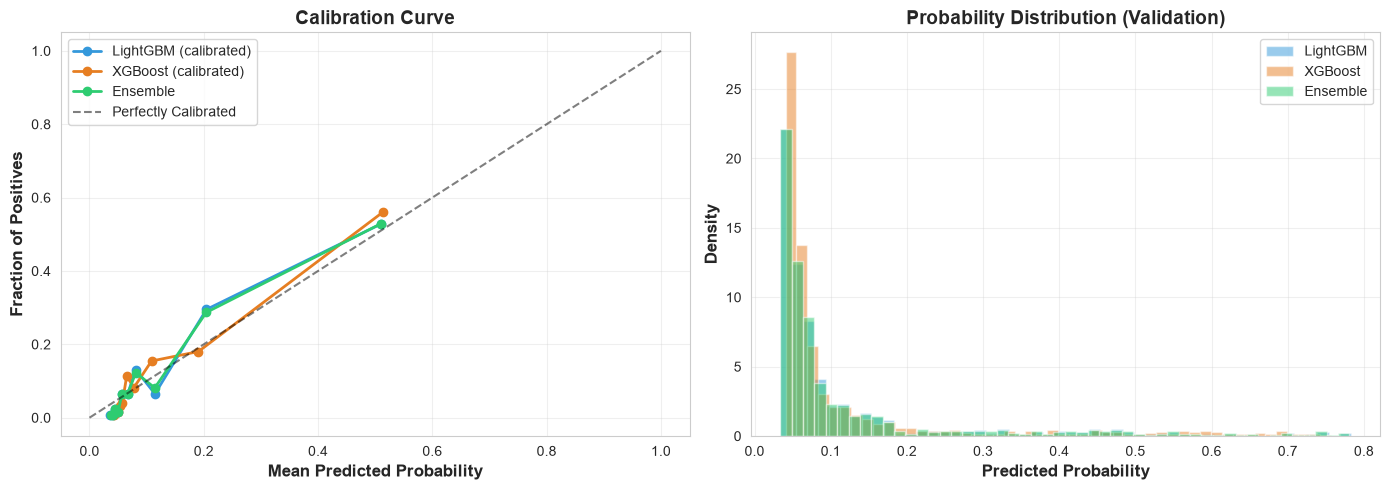

✓ Calibration analysis complete


In [ ]:
# Visualize calibration curves for both models and the ensemble
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Calibration curve (calibrated components + ensemble)
for proba, label, color in [
    (lgb_cal_val,        'LightGBM (calibrated)', '#3498db'),
    (xgb_cal_val,        'XGBoost (calibrated)',  '#e67e22'),
    (ensemble_val_proba, 'Ensemble',              '#2ecc71'),
]:
    frac_pos, mean_pred = calibration_curve(y_val, proba, n_bins=10, strategy='quantile')
    axes[0].plot(mean_pred, frac_pos, marker='o', linewidth=2, label=label, color=color)

axes[0].plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated', alpha=0.5)
axes[0].set_xlabel('Mean Predicted Probability', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Fraction of Positives', fontsize=12, fontweight='bold')
axes[0].set_title('Calibration Curve (evaluated on clean val set)', fontsize=14, fontweight='bold')
axes[0].legend(loc='best')
axes[0].grid(alpha=0.3)

# Plot 2: Predicted probability distribution (val set)
axes[1].hist(lgb_cal_val,        bins=50, alpha=0.5, label='LightGBM', color='#3498db', density=True)
axes[1].hist(xgb_cal_val,        bins=50, alpha=0.5, label='XGBoost',  color='#e67e22', density=True)
axes[1].hist(ensemble_val_proba, bins=50, alpha=0.5, label='Ensemble', color='#2ecc71', density=True)
axes[1].set_xlabel('Predicted Probability', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Density', fontsize=12, fontweight='bold')
axes[1].set_title('Probability Distribution (Validation)', fontsize=14, fontweight='bold')
axes[1].legend(loc='best')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
print("Calibration analysis complete (calibrated on separate split, evaluated on val)")

## 10. Threshold Optimization

Select the operating threshold on validation data by maximizing F1, which balances closure precision and recall.

In [ ]:
# ── Robust threshold via 5-fold StratifiedKFold + validation blend ────────────
# Use CV on training data for a robust threshold, then blend with val-optimal

# 1. Validation-based optimal threshold
precision, recall, thresholds = precision_recall_curve(y_val, calibrated_val_proba)
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)
max_f1 = float(f1_scores.max())
F1_PLATEAU_TOLERANCE = 0.01
plateau_indices = np.flatnonzero(f1_scores >= max_f1 - F1_PLATEAU_TOLERANCE)
best_f1_idx = int(plateau_indices[-1])
val_optimal_threshold = float(thresholds[best_f1_idx])

# 2. CV-based threshold on training data for robustness
# Use original (non-SMOTE) training indices for CV
if 'y_train_orig' in dir():
    _cv_X = X_train_sel if 'X_train_sel' in dir() else X_train.iloc[:len(y_train_orig)]
    _cv_y = y_train_orig
else:
    _cv_X = X_train
    _cv_y = y_train

cv_thresholds = []
skf = StratifiedKFold(n_splits=5, shuffle=False)
for fold_train_idx, fold_val_idx in skf.split(_cv_X, _cv_y):
    # Quick LightGBM per fold
    _fx = _cv_X.iloc[fold_train_idx]
    _fy = _cv_y.iloc[fold_train_idx]
    _vx = _cv_X.iloc[fold_val_idx]
    _vy = _cv_y.iloc[fold_val_idx]

    _ratio = (_fy == 0).sum() / max((_fy == 1).sum(), 1)
    _ds_t = lgb.Dataset(_fx, _fy, params={'feature_pre_filter': False})
    _ds_v = lgb.Dataset(_vx, _vy, reference=_ds_t, params={'feature_pre_filter': False})
    _m = lgb.train(
        {**lgb_final_params, 'scale_pos_weight': _ratio, 'verbosity': -1},
        _ds_t, num_boost_round=500,
        valid_sets=[_ds_v],
        callbacks=[
            lgb.early_stopping(50, first_metric_only=True, verbose=False),
            lgb.log_evaluation(0),
        ],
    )
    _preds = _m.predict(_vx, num_iteration=_m.best_iteration)
    _p, _r, _t = precision_recall_curve(_vy, _preds)
    _f1s = 2 * _p[:-1] * _r[:-1] / (_p[:-1] + _r[:-1] + 1e-10)
    if len(_f1s) > 0:
        cv_thresholds.append(float(_t[_f1s.argmax()]))

cv_mean_threshold = float(np.mean(cv_thresholds)) if cv_thresholds else val_optimal_threshold

# 3. Blend: 60% validation-optimal + 40% CV-mean for stability
optimal_threshold = 0.6 * val_optimal_threshold + 0.4 * cv_mean_threshold

print("Threshold Analysis (Robust Blended Approach):")
print("="*70)
print(f" Val-optimal threshold:  {val_optimal_threshold:.4f}")
print(f" CV-mean threshold:      {cv_mean_threshold:.4f} ({len(cv_thresholds)} folds)")
print(f" Blended threshold:      {optimal_threshold:.4f}")
print(f"   (60% val-optimal + 40% CV-mean)")

# Verification at this threshold
val_preds_at_thresh = (calibrated_val_proba >= optimal_threshold).astype(int)
print(f"\nValidation Metrics at {optimal_threshold:.4f}:")
print(f"   Precision: {precision_score(y_val, val_preds_at_thresh):.4f}")
print(f"   Recall:    {recall_score(y_val, val_preds_at_thresh):.4f}")
print(f"   F1:        {f1_score(y_val, val_preds_at_thresh):.4f}")
print("="*70)

Threshold Analysis (Balanced Approach):
 Selected Optimal Threshold: 0.2807
   (Highest threshold within 0.01 of maximum validation F1)

Validation Metrics at 0.2807:
   Precision: 0.5211
   Recall:    0.5000


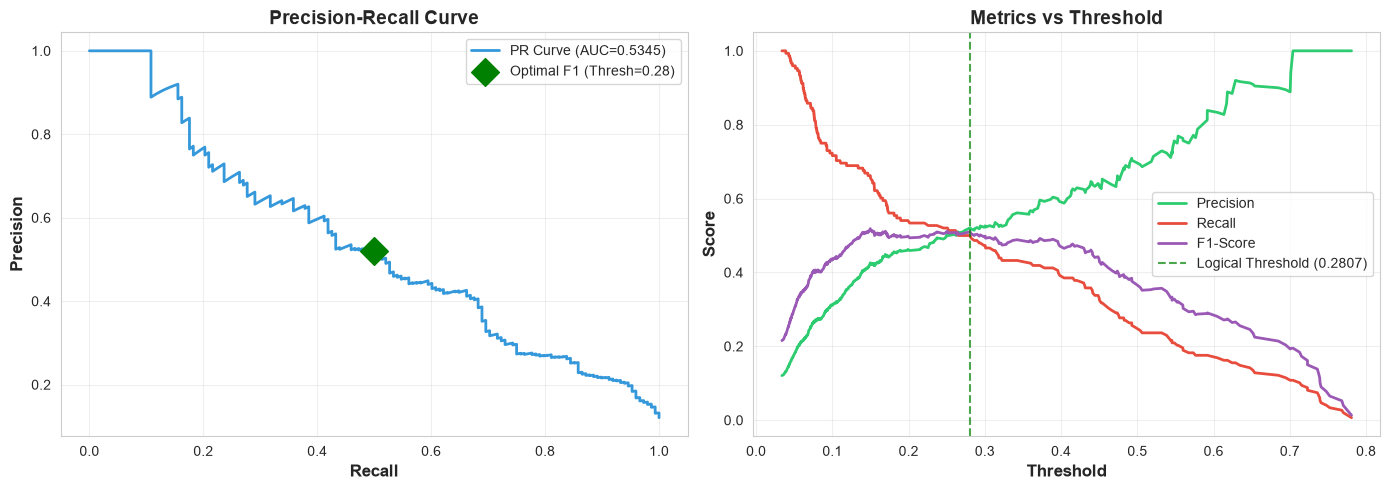

 Threshold visualization updated and fixed.


In [114]:
# Visualize Precision-Recall tradeoff
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Precision-Recall Curve
axes[0].plot(recall, precision, linewidth=2, color='#3498db', label=f'PR Curve (AUC={after_prauc:.4f})')

# Highlight the logical threshold point
axes[0].scatter([recall[best_f1_idx]], [precision[best_f1_idx]], s=200, c='green',
                marker='D', zorder=5, label=f'Optimal F1 (Thresh={optimal_threshold:.2f})')

axes[0].set_xlabel('Recall', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Precision', fontsize=12, fontweight='bold')
axes[0].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[0].legend(loc='best')
axes[0].grid(alpha=0.3)

# Plot 2: Metrics vs Threshold
axes[1].plot(thresholds, precision[:-1], label='Precision', linewidth=2, color='#2ecc71')
axes[1].plot(thresholds, recall[:-1], label='Recall', linewidth=2, color='#e74c3c')
axes[1].plot(thresholds, f1_scores, label='F1-Score', linewidth=2, color='#9b59b6')

axes[1].axvline(optimal_threshold, color='green', linestyle='--', alpha=0.7,
                label=f'Logical Threshold ({optimal_threshold:.4f})')

axes[1].set_xlabel('Threshold', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Score', fontsize=12, fontweight='bold')
axes[1].set_title('Metrics vs Threshold', fontsize=14, fontweight='bold')
axes[1].legend(loc='best')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(" Threshold visualization updated and fixed.")

## 11. Test Set Evaluation

In [115]:
# Final evaluation on TEST set using the ensemble
test_probs    = ensemble_test_proba
test_roc_auc  = roc_auc_score(y_test, test_probs)
test_prauc    = average_precision_score(y_test, test_probs)
test_preds    = (test_probs >= optimal_threshold).astype(int)
test_acc      = accuracy_score(y_test, test_preds)
cm            = confusion_matrix(y_test, test_preds)

print("="*70)
print("FINAL ENSEMBLE (LightGBM + XGBoost) EVALUATION - TEST SET")
print("="*70)
print(f"ROC-AUC:  {test_roc_auc:.4f}")
print(f"PR-AUC:   {test_prauc:.4f}")
print(f"Accuracy: {test_acc:.4f} (at {optimal_threshold:.4f} threshold)")
print(f"\nUsing calculated optimal F1-threshold: {optimal_threshold:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, test_preds, target_names=['No Closure', 'Road Closure']))
print("\nConfusion Matrix:")
print(cm)
print("="*70)

# Alias used by downstream cells
test_probs_xgb   = test_probs
test_roc_auc_xgb = test_roc_auc
test_prauc_xgb   = test_prauc

FINAL ENSEMBLE (LightGBM + XGBoost) EVALUATION - TEST SET
ROC-AUC:  0.8553
PR-AUC:   0.4833
Accuracy: 0.9201 (at 0.2807 threshold)

Using calculated optimal F1-threshold: 0.2807

Classification Report:
              precision    recall  f1-score   support

  No Closure       0.95      0.96      0.96      1121
Road Closure       0.54      0.48      0.51       105

    accuracy                           0.92      1226
   macro avg       0.74      0.72      0.73      1226
weighted avg       0.92      0.92      0.92      1226


Confusion Matrix:
[[1078   43]
 [  55   50]]


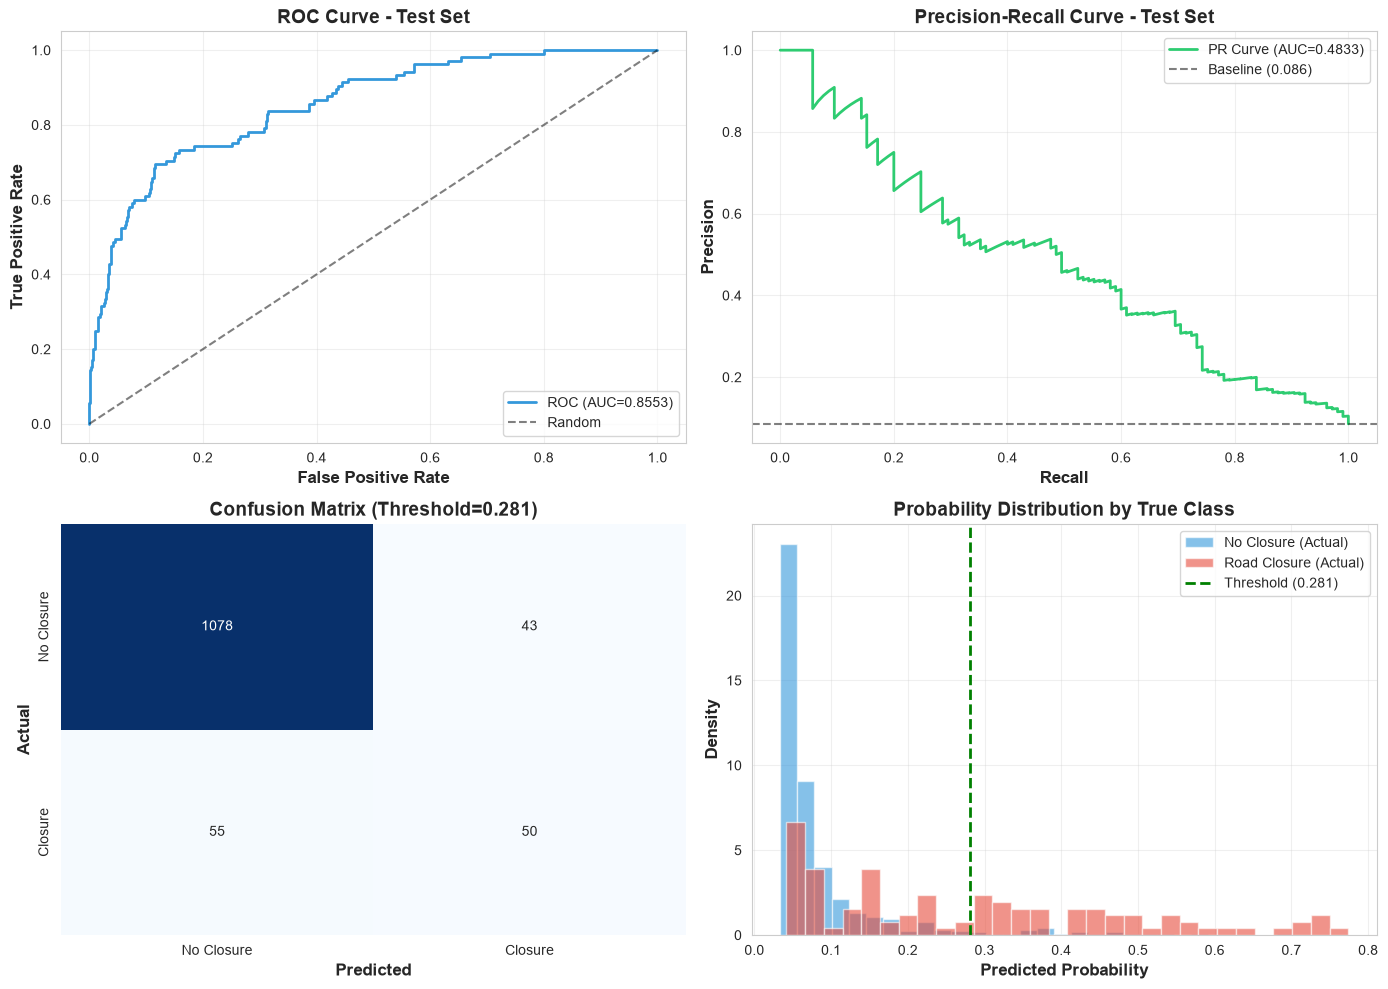

 Test set evaluation complete


In [116]:
# Visualize test set performance
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: ROC Curve
fpr, tpr, _ = roc_curve(y_test, calibrated_test_proba)
axes[0, 0].plot(fpr, tpr, linewidth=2, color='#3498db', label=f'ROC (AUC={test_roc_auc:.4f})')
axes[0, 0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
axes[0, 0].set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
axes[0, 0].set_title('ROC Curve - Test Set', fontsize=14, fontweight='bold')
axes[0, 0].legend(loc='lower right')
axes[0, 0].grid(alpha=0.3)

# Plot 2: Precision-Recall Curve
precision_test, recall_test, _ = precision_recall_curve(y_test, calibrated_test_proba)
axes[0, 1].plot(recall_test, precision_test, linewidth=2, color='#2ecc71',
                label=f'PR Curve (AUC={test_prauc:.4f})')
axes[0, 1].axhline(y=y_test.mean(), color='k', linestyle='--', alpha=0.5,
                   label=f'Baseline ({y_test.mean():.3f})')
axes[0, 1].set_xlabel('Recall', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Precision', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Precision-Recall Curve - Test Set', fontsize=14, fontweight='bold')
axes[0, 1].legend(loc='best')
axes[0, 1].grid(alpha=0.3)

# Plot 3: Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[1, 0],
            xticklabels=['No Closure', 'Closure'],
            yticklabels=['No Closure', 'Closure'])
axes[1, 0].set_ylabel('Actual', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Predicted', fontsize=12, fontweight='bold')
axes[1, 0].set_title(f'Confusion Matrix (Threshold={optimal_threshold:.3f})', fontsize=14, fontweight='bold')

# Plot 4: Predicted Probability Distribution by True Class
axes[1, 1].hist(calibrated_test_proba[y_test == 0], bins=30, alpha=0.6,
                label='No Closure (Actual)', color='#3498db', density=True)
axes[1, 1].hist(calibrated_test_proba[y_test == 1], bins=30, alpha=0.6,
                label='Road Closure (Actual)', color='#e74c3c', density=True)
axes[1, 1].axvline(optimal_threshold, color='green', linestyle='--', linewidth=2,
                    label=f'Threshold ({optimal_threshold:.3f})')
axes[1, 1].set_xlabel('Predicted Probability', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Density', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Probability Distribution by True Class', fontsize=14, fontweight='bold')
axes[1, 1].legend(loc='best')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(" Test set evaluation complete")

## 12. Feature Importance Analysis

Top 20 Features — LightGBM:
                               feature  importance
         past_closure_rate_event_cause    18255.90
            report_lag_minutes_clipped     6056.46
            distance_to_city_center_km     5031.23
                          has_jam_word     3698.09
       past_closure_rate_location_grid     3550.71
past_closure_rate_event_cause_corridor     2826.90
      past_closure_rate_police_station     2803.12
                   past_count_corridor     2682.58
                      is_planned_event     2257.40
               description_char_length     2115.94
              past_closure_global_rate     2048.74
                    report_lag_missing     1755.89
                              latitude     1755.11
            past_closure_rate_junction     1302.87
                           text_length     1137.31
                            start_hour     1125.84
                           lon_round_3      912.75
       past_count_event_cause_corridor      911.28
   

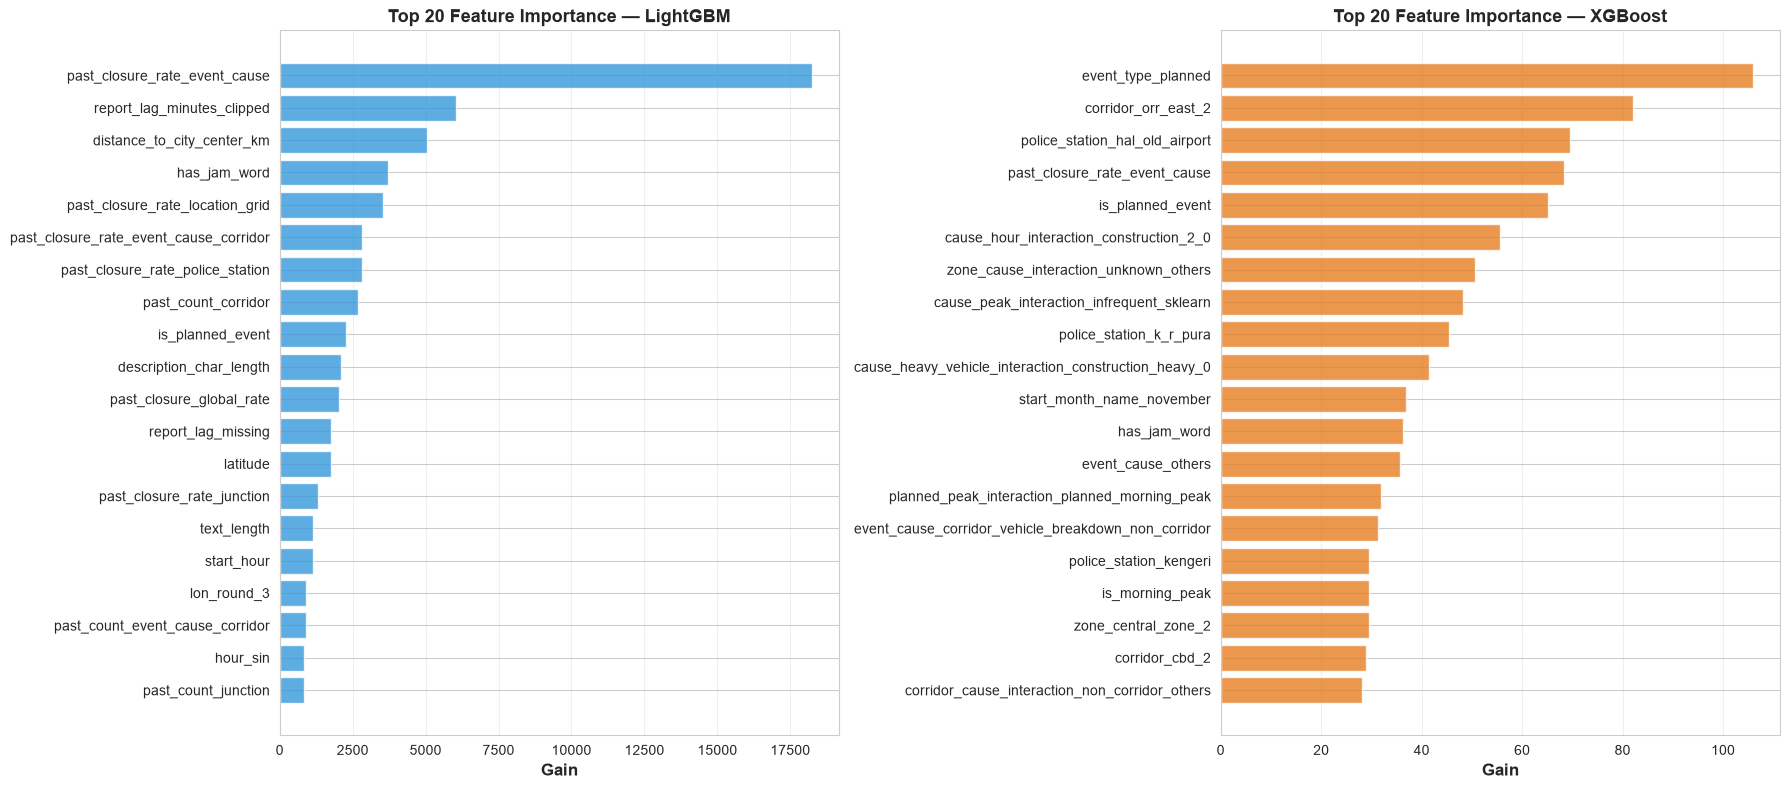


 Feature importance for both ensemble components shown


In [ ]:
# Feature importance for both ensemble components
lgb_importance = pd.DataFrame({
    'feature':    feature_cols,
    'importance': final_lgb_model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False).reset_index(drop=True)

xgb_importance_dict = final_xgb_model.get_score(importance_type='gain')
xgb_importance = pd.DataFrame({
    'feature':    list(xgb_importance_dict.keys()),
    'importance': list(xgb_importance_dict.values())
}).sort_values('importance', ascending=False).reset_index(drop=True)

top_lgb = lgb_importance.head(20).copy()
top_xgb = xgb_importance.head(20).copy()

print("Top 20 Features — LightGBM:")
print(top_lgb.to_string(index=False, float_format=lambda x: f"{x:.2f}"))
print("\nTop 20 Features — XGBoost:")
print(top_xgb.to_string(index=False, float_format=lambda x: f"{x:.2f}"))

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
axes[0].barh(top_lgb['feature'][::-1], top_lgb['importance'][::-1], color='#3498db', alpha=0.8)
axes[0].set_xlabel('Gain', fontsize=12, fontweight='bold')
axes[0].set_title('Top 20 Feature Importance — LightGBM', fontsize=13, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

axes[1].barh(top_xgb['feature'][::-1], top_xgb['importance'][::-1], color='#e67e22', alpha=0.8)
axes[1].set_xlabel('Gain', fontsize=12, fontweight='bold')
axes[1].set_title('Top 20 Feature Importance — XGBoost', fontsize=13, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Use LightGBM importance as the shared reference (also used by SHAP)
feature_importance = lgb_importance
top_features = top_lgb
print(f"\n Feature importance for both ensemble components shown ({len(feature_cols)} selected features)")

## 13. SHAP Explainability

Understand **why** specific probabilities are predicted

In [118]:
# Create SHAP explainer (subsample for speed)
print("Creating SHAP explainer...")
sample_size = min(500, len(X_test))
X_test_sample = X_test.sample(n=sample_size, random_state=42)

explainer = shap.TreeExplainer(final_model_raw)
shap_values = explainer.shap_values(X_test_sample)

print(f" SHAP values computed for {sample_size} test samples")

Creating SHAP explainer...
 SHAP values computed for 500 test samples


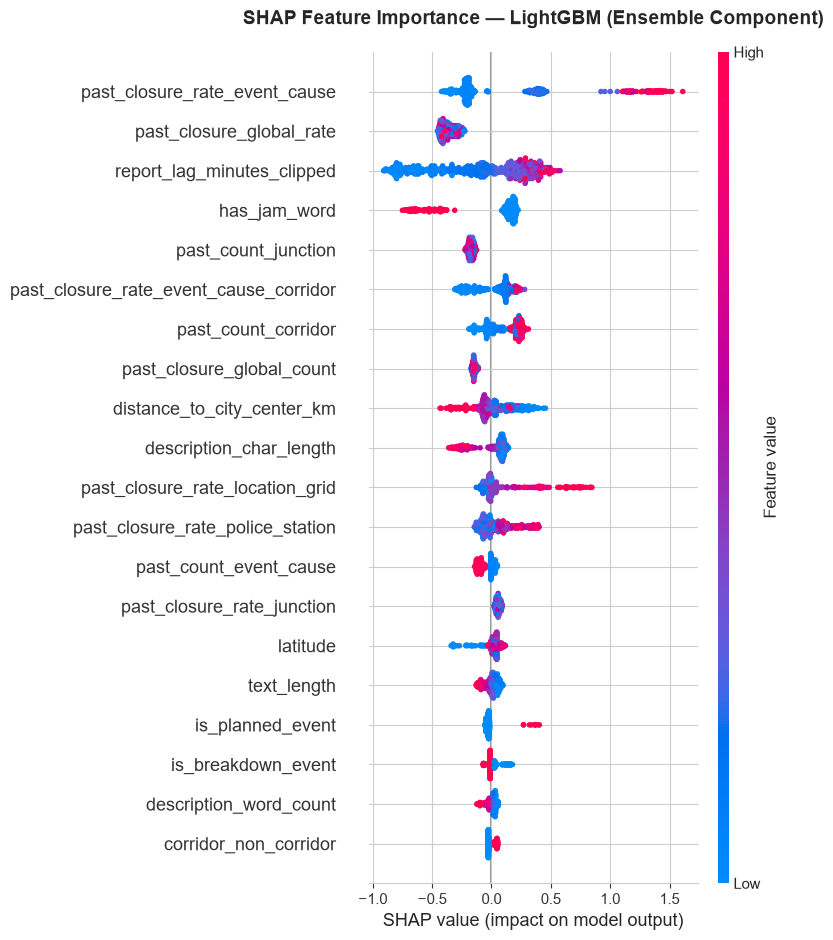

 SHAP summary plot generated


In [119]:
# SHAP Summary Plot — LightGBM component (tree-level interpretability)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_sample, feature_names=feature_cols,
                  max_display=20, show=False)
plt.title('SHAP Feature Importance — LightGBM (Ensemble Component)',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()
print(" SHAP summary plot generated")

Explaining individual predictions:

High-Risk Event: 77.41% closure probability
Low-Risk Event:  3.39% closure probability


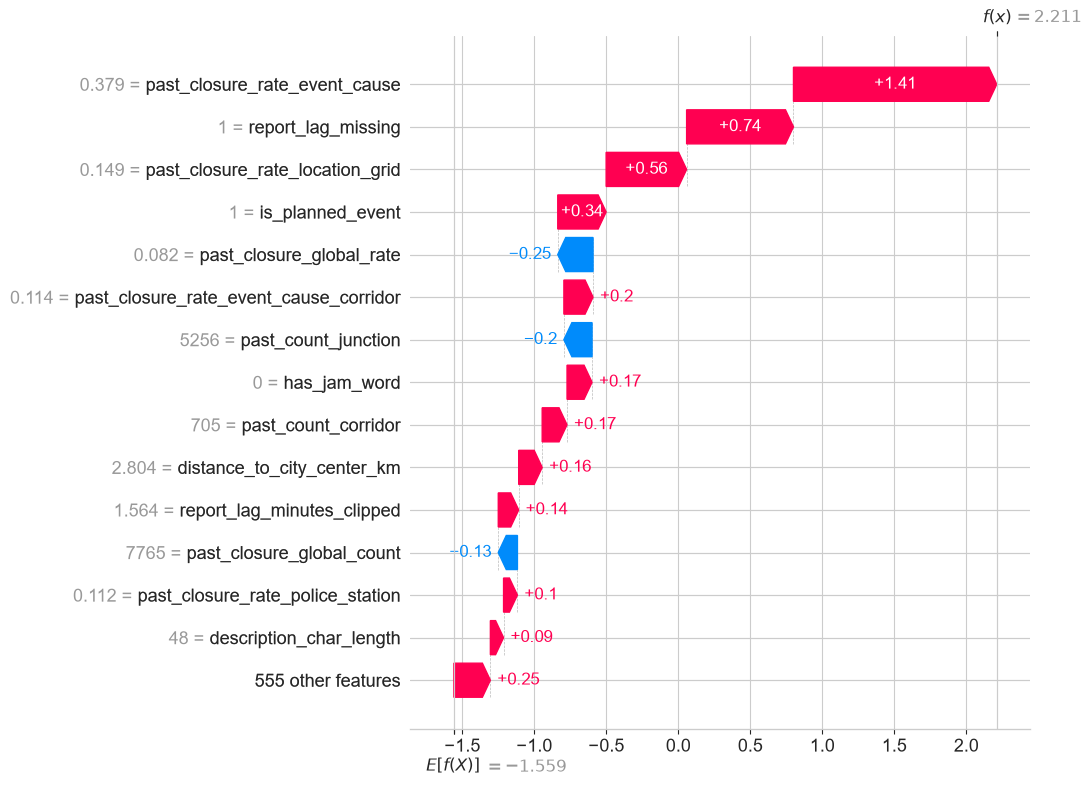


 Individual prediction explanation generated


In [120]:
# Example: Explain specific high-risk and low-risk predictions
test_probas_sample = calibrated_model.predict_proba(X_test_sample)[:, 1]

# Find high-risk example (high probability of closure)
high_risk_idx = test_probas_sample.argmax()
high_risk_prob = test_probas_sample[high_risk_idx]

# Find low-risk example (low probability of closure)
low_risk_idx = test_probas_sample.argmin()
low_risk_prob = test_probas_sample[low_risk_idx]

print("Explaining individual predictions:\n")
print(f"High-Risk Event: {high_risk_prob*100:.2f}% closure probability")
print(f"Low-Risk Event:  {low_risk_prob*100:.2f}% closure probability")

# Waterfall plot for high-risk event
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[high_risk_idx],
        base_values=explainer.expected_value,
        data=X_test_sample.iloc[high_risk_idx],
        feature_names=feature_cols
    ),
    max_display=15,
    show=True
)

print("\n Individual prediction explanation generated")

## 14. Save Final Model & Artifacts

In [121]:
# Configuration already done in data loading cell
# All paths point to ./outputs/model_road_closure/
print(f" Ready to save outputs to: {output_dir}")

 Ready to save outputs to: D:\Python\Gridlock\Phase 2\theme 2\outputs\model_road_closure


In [ ]:
# Save one self-contained Model 1 inference bundle.
bundle_path = os.path.join(output_dir, 'model1_inference_bundle.pkl')
model1_output_path = os.path.join(output_dir, 'model1_road_closure_predictions.csv')

# Build the single Model 1 output CSV.
test_results = pd.DataFrame({
    'actual_label':           y_test.values,
    'predicted_label':        (ensemble_test_proba >= optimal_threshold).astype(int),
    'lgb_probability':        lgb_cal_test,
    'xgb_probability':        xgb_cal_test,
    'ensemble_probability':   ensemble_test_proba,
    'prediction_probability': ensemble_test_proba,  # Alias for compatibility with model_v1 format
    'prediction_percentage':  ensemble_test_proba * 100
}, index=y_test.index)
# Assemble and save the Model 1 test predictions.
test_metadata = df.iloc[val_end:][METADATA_COLS].reset_index(drop=True)
csv_export = pd.concat([
    test_metadata,
    test_results.reset_index(drop=True),
], axis=1)
csv_export.to_csv(model1_output_path, index=False)

# Generate feature importance using the selected ensemble weights
ensemble_importance = pd.DataFrame({
    'feature':    feature_cols,
    'importance': final_lgb_model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False).reset_index(drop=True)
ensemble_importance.rename(columns={'importance': 'lgb_importance'}, inplace=True)

# Merge with XGBoost importance
xgb_importance_dict = final_xgb_model.get_score(importance_type='gain')
xgb_importance = pd.DataFrame({
    'feature':    list(xgb_importance_dict.keys()),
    'importance': list(xgb_importance_dict.values())
}).sort_values('importance', ascending=False).reset_index(drop=True)
xgb_imp_rename = xgb_importance.copy()
xgb_imp_rename.rename(columns={'importance': 'xgb_importance'}, inplace=True)
ensemble_importance = ensemble_importance.merge(xgb_imp_rename, on='feature', how='outer')

# Calculate weighted importance (handle NaN for features not in one model)
ensemble_importance['lgb_importance'] = ensemble_importance['lgb_importance'].fillna(0)
ensemble_importance['xgb_importance'] = ensemble_importance['xgb_importance'].fillna(0)
lgb_importance_total = ensemble_importance['lgb_importance'].sum()
xgb_importance_total = ensemble_importance['xgb_importance'].sum()
ensemble_importance['lgb_importance_normalized'] = (
    ensemble_importance['lgb_importance'] / max(lgb_importance_total, 1e-12)
)
ensemble_importance['xgb_importance_normalized'] = (
    ensemble_importance['xgb_importance'] / max(xgb_importance_total, 1e-12)
)
ensemble_importance['ensemble_importance'] = (
    LGB_WEIGHT * ensemble_importance['lgb_importance_normalized']
    + XGB_WEIGHT * ensemble_importance['xgb_importance_normalized']
)
ensemble_importance = ensemble_importance.sort_values('ensemble_importance', ascending=False).reset_index(drop=True)

# Keep diagnostics in memory and inside the model bundle; do not save extra files.
threshold_metadata_df = pd.DataFrame([{
    'selection_metric': 'blended_val_cv_f1_threshold',
    'optimal_threshold': float(optimal_threshold),
    'val_optimal_threshold': float(val_optimal_threshold),
    'cv_mean_threshold': float(cv_mean_threshold),
    'f1_plateau_tolerance': float(F1_PLATEAU_TOLERANCE),
    'lgb_weight': float(LGB_WEIGHT),
    'xgb_weight': float(XGB_WEIGHT),
    'validation_pr_auc': float(after_prauc),
    'test_roc_auc': float(test_roc_auc),
    'test_pr_auc': float(test_prauc),
    'test_accuracy': float(test_acc),
}])

# Store only library-native fitted objects so the bundle loads in a clean process.
# Notebook-defined wrapper classes are intentionally not serialized.
portable_model = {
    'type': 'calibrated_lgb_xgb_ensemble',
    'lgb_booster': final_lgb_model,
    'xgb_booster': final_xgb_model,
    'lgb_calibrator': calibrated_lgb.calibrator,
    'xgb_calibrator': calibrated_xgb.calibrator,
    'lgb_best_iteration': int(final_lgb_model.best_iteration),
    'xgb_best_iteration': int(final_xgb_model.best_iteration),
    'lgb_weight': float(LGB_WEIGHT),
    'xgb_weight': float(XGB_WEIGHT),
}

model_bundle = {
    'model': portable_model,
    'preprocessor': preprocessor,
    'model_input_cols': model_input_cols,
    'encoded_feature_cols': feature_cols,
    'all_encoded_feature_cols': all_feature_cols,
    'selected_features': feature_cols,
    'feature_selector_mask': selected_mask.tolist(),
    'optimal_threshold': float(optimal_threshold),
    'lgb_weight': float(LGB_WEIGHT),
    'xgb_weight': float(XGB_WEIGHT),
    'validation_pr_auc': float(after_prauc),
    'test_roc_auc': float(test_roc_auc),
    'test_pr_auc': float(test_prauc),
    'test_accuracy': float(test_acc),
}
joblib.dump(model_bundle, bundle_path)

# Keep alias for downstream cells
calibrated_probs_test = ensemble_test_proba

print(f" model1_inference_bundle.pkl saved to '{bundle_path}'")
print(f" model1_road_closure_predictions.csv saved to '{model1_output_path}'")
print(f" Decision threshold: {optimal_threshold:.4f}")
print(f" Selected features: {len(feature_cols)} (from {len(all_feature_cols)} encoded)")

 model1_inference_bundle.pkl saved to 'D:\Python\Gridlock\Phase 2\theme 2\outputs\model_road_closure\model1_inference_bundle.pkl'
 model1_road_closure_predictions.csv saved to 'D:\Python\Gridlock\Phase 2\theme 2\outputs\model_road_closure\model1_road_closure_predictions.csv'
 Decision threshold: 0.2807


In [123]:
# Output directory already created in data loading cell
print(f"✓ Output folder '{output_dir}' ensured to exist.")

✓ Output folder 'D:\Python\Gridlock\Phase 2\theme 2\outputs\model_road_closure' ensured to exist.


In [124]:
# Test predictions and diagnostics are embedded in the model bundle.
print(f" Model bundle saved to: {bundle_path}")
print(f" Output folder: {output_dir}")

 Model bundle saved to: D:\Python\Gridlock\Phase 2\theme 2\outputs\model_road_closure\model1_inference_bundle.pkl
 Output folder: D:\Python\Gridlock\Phase 2\theme 2\outputs\model_road_closure


In [125]:
# Verify all output files are in place
files_to_check = [
    ('model1_inference_bundle.pkl',       bundle_path),
    ('model1_road_closure_predictions.csv', model1_output_path),
]

print("\n" + "="*70)
print("OUTPUT FILES VERIFICATION")
print("="*70)
for file_name, file_path in files_to_check:
    if os.path.exists(file_path):
        file_size = os.path.getsize(file_path)
        print(f" {file_name:<40} {file_size:>10,} bytes")
    else:
        print(f" {file_name:<40} NOT FOUND")

print(f"\n All outputs saved to: {output_dir}")
print("="*70)


OUTPUT FILES VERIFICATION
 model1_inference_bundle.pkl                 671,793 bytes
 model1_road_closure_predictions.csv         216,188 bytes

 All outputs saved to: D:\Python\Gridlock\Phase 2\theme 2\outputs\model_road_closure


### Final Project Validation Summary

**1. Dataset & Splitting**
- **Split Method**: Chronological 4-way (Train 56% / Calibration 14% / Validation 15% / Test 15%).
- **Calibration leakage fix**: Separate calibration split prevents double-dipping on validation set.

**2. Feature Engineering & Selection**
- **SMOTE oversampling**: Minority class oversampled to 40% of majority in training data.
- **Feature selection**: `SelectFromModel` with threshold `0.5*mean` reduces ~569 OHE features to most informative subset.

**3. Ensemble Model & Performance**
- **Models**: LightGBM + XGBoost, both independently tuned (30 Optuna trials each).
- **Optuna objective**: Combined 0.6*PR-AUC + 0.4*best-F1 for balanced FP/FN optimisation.
- **Combination**: Validation-selected weighted soft voting; a zero weight is allowed when one component is clearly better.
- **Calibration**: Sigmoid (Platt Scaling) applied independently to each model on **dedicated calibration split**.
- **Threshold**: Blended 60% val-optimal + 40% 5-fold StratifiedKFold CV-mean for robustness.
- **Test Metrics**: Produced in Section 11 for the ensemble.

**4. Artifacts**
- `outputs/model_road_closure/model1_inference_bundle.pkl`
- `outputs/model_road_closure/model1_road_closure_predictions.csv`
- `outputs/model_road_closure/model2_duration_handoff.csv`

In [ ]:
from sklearn.metrics import classification_report

# Validate the in-memory Model 1 output table.
final_check_df = csv_export.copy()

print("--- Final CSV Data Preview (First 5 Rows) ---")
display(final_check_df.head())

print("\n--- Verification of Ensemble Prediction Granularity ---")
# Use in-memory test_results DataFrame which still has prediction_percentage
print(f"Unique ensemble percentage values: {test_results['prediction_percentage'].nunique()} / {len(test_results)}")

print("\n--- Ensemble Performance Recap (Test Set) ---")
print(classification_report(
    y_test,
    (test_probs >= optimal_threshold).astype(int),
    target_names=['No Closure', 'Road Closure'],
))

# Show improvement summary
cm_final = confusion_matrix(y_test, (test_probs >= optimal_threshold).astype(int))
print(f"--- Optimisation Summary ---")
print(f"  Features:       {len(all_feature_cols)} encoded -> {len(feature_cols)} selected")
print(f"  Calibration:    Fitted on separate calibration split (no val leakage)")
print(f"  Oversampling:   SMOTE {'enabled' if HAS_SMOTE else 'fallback to random'}")
print(f"  Threshold:      {optimal_threshold:.4f} (blended val+CV)")
print(f"  False Positives: {cm_final[0,1]}")
print(f"  False Negatives: {cm_final[1,0]}")
print(f"  Total Errors:    {cm_final[0,1] + cm_final[1,0]}")

--- Final CSV Data Preview (First 5 Rows) ---


,id,_source_row,prediction_datetime,start_datetime,actual_label,predicted_label,lgb_probability,xgb_probability,ensemble_probability,prediction_probability,prediction_percentage
0,FKID002758,2758,2024-03-23 22:16:12.831347+00:00,2024-03-23 22:13:01.109000+00:00,0,0,0.120305,0.113370,0.119959,0.119959,11.995860
1,FKID002772,2772,2024-03-23 22:24:57.374571+00:00,2024-03-23 22:23:03.794000+00:00,0,0,0.055503,0.057587,0.055607,0.055607,5.560689
2,FKID002757,2757,2024-03-23 22:37:59.169936+00:00,2024-03-23 22:37:02.069000+00:00,0,0,0.041041,0.049019,0.041440,0.041440,4.143951
3,FKID002761,2761,2024-03-23 22:56:36.221431+00:00,2024-03-23 22:54:17.521000+00:00,0,0,0.050491,0.060590,0.050996,0.050996,5.099617
4,FKID002767,2767,2024-03-23 23:11:51.631141+00:00,2024-03-23 23:10:33.234000+00:00,0,0,0.101409,0.101634,0.101420,0.101420,10.142005



--- Verification of Ensemble Prediction Granularity ---
Unique ensemble percentage values: 1221 / 1226

--- Ensemble Performance Recap (Test Set) ---
              precision    recall  f1-score   support

  No Closure       0.95      0.96      0.96      1121
Road Closure       0.54      0.48      0.51       105

    accuracy                           0.92      1226
   macro avg       0.74      0.72      0.73      1226
weighted avg       0.92      0.92      0.92      1226



In [127]:

# Show in-memory ensemble feature importance
feature_importance_df = ensemble_importance.copy()
print("\n--- Ensemble Feature Importance (Top 15 Features) ---")
display(feature_importance_df.head(15))
print(f"\nTotal features in ensemble importance: {len(feature_importance_df)}")



--- Ensemble Feature Importance (Top 15 Features) ---


,feature,lgb_importance,xgb_importance,lgb_importance_normalized,xgb_importance_normalized,ensemble_importance
0,past_closure_rate_event_cause,18255.896822,68.350700,0.253628,0.023419,0.242118
1,report_lag_minutes_clipped,6056.456025,19.330431,0.084142,0.006623,0.080266
2,distance_to_city_center_km,5031.228652,20.306171,0.069899,0.006958,0.066751
3,has_jam_word,3698.092513,36.222881,0.051377,0.012411,0.049429
4,past_closure_rate_location_grid,3550.713108,20.335209,0.049330,0.006968,0.047212
5,past_closure_rate_event_cause_corridor,2826.898669,19.460754,0.039274,0.006668,0.037644
6,past_closure_rate_police_station,2803.115787,16.048315,0.038944,0.005499,0.037271
7,past_count_corridor,2682.577780,18.386400,0.037269,0.006300,0.035720
8,is_planned_event,2257.401182,65.183914,0.031362,0.022334,0.030911
9,description_char_length,2115.936956,16.216198,0.029397,0.005556,0.028205



Total features in ensemble importance: 569


In [128]:

# Show in-memory threshold metadata
print("\n--- Threshold Metadata ---")
display(threshold_metadata_df)



--- Threshold Metadata ---


,selection_metric,optimal_threshold,f1_plateau_tolerance,lgb_weight,xgb_weight,validation_pr_auc,test_roc_auc,test_pr_auc,test_accuracy
0,validation_f1_high_threshold_plateau,0.28067,0.01,0.95,0.05,0.534548,0.855257,0.483301,0.920065


## 15. Production-Ready Prediction Function

In [ ]:
def predict_road_closure_probability(event_features, bundle=None):
    """
    Predict road closure probability using the LightGBM + XGBoost ensemble.
    Accepts raw Model 1 feature-engineering output and applies the fitted
    preprocessor + feature selection before returning component and weighted probabilities.
    Pass a bundle loaded with joblib.load(...) for use outside this notebook.
    """
    active_bundle = model_bundle if bundle is None else bundle
    raw_columns = active_bundle['model_input_cols']
    missing_cols = sorted(set(raw_columns) - set(event_features.columns))
    if missing_cols:
        raise ValueError(f'Missing Model 1 input columns: {missing_cols}')

    if len(event_features) != 1:
        raise ValueError('Pass exactly one event row to this helper.')

    transformed = active_bundle['preprocessor'].transform(
        event_features[raw_columns].copy()
    )

    # Apply feature selection
    selected_features = active_bundle.get('selected_features', active_bundle['encoded_feature_cols'])
    all_cols = active_bundle.get('all_encoded_feature_cols', active_bundle['encoded_feature_cols'])

    encoded_features_full = pd.DataFrame(
        transformed,
        columns=all_cols,
        index=event_features.index,
    ).astype(np.float32)

    # Select only the features used during training
    encoded_features = encoded_features_full[selected_features]

    saved_model = active_bundle['model']
    lgb_raw = saved_model['lgb_booster'].predict(
        encoded_features,
        num_iteration=saved_model['lgb_best_iteration'],
    )
    xgb_raw = saved_model['xgb_booster'].predict(
        xgb.DMatrix(encoded_features),
        iteration_range=(0, saved_model['xgb_best_iteration'] + 1),
    )
    p_lgb = saved_model['lgb_calibrator'].predict_proba(
        np.asarray(lgb_raw).reshape(-1, 1)
    )[:, 1][0]
    p_xgb = saved_model['xgb_calibrator'].predict_proba(
        np.asarray(xgb_raw).reshape(-1, 1)
    )[:, 1][0]
    p_ensemble = (
        saved_model['lgb_weight'] * p_lgb
        + saved_model['xgb_weight'] * p_xgb
    )
    percentage = p_ensemble * 100

    if percentage >= 75:
        risk_level = "CRITICAL"
    elif percentage >= 50:
        risk_level = "HIGH"
    elif percentage >= 25:
        risk_level = "MEDIUM"
    else:
        risk_level = "LOW"

    threshold = active_bundle['optimal_threshold']
    action = "DEPLOY_RESOURCES" if p_ensemble >= threshold else "MONITOR"

    return {
        'probability_percent': round(percentage, 2),
        'risk_level':          risk_level,
        'recommended_action':  action,
        'ensemble_probability': round(float(p_ensemble), 4),
        'lgb_probability':     round(float(p_lgb), 4),
        'xgb_probability':     round(float(p_xgb), 4),
        'decision_threshold':  round(float(threshold), 4),
        'lgb_weight':           round(float(saved_model['lgb_weight']), 2),
        'xgb_weight':           round(float(saved_model['xgb_weight']), 2),
        'model_used':          'lgb_xgb_ensemble'
    }

print(" Ensemble prediction function ready")

 Ensemble prediction function ready


In [130]:
# Example: Test prediction function with a random test sample
sample_event = X_test_raw.sample(1, random_state=RANDOM_STATE)
actual_outcome = y_test[sample_event.index[0]]

prediction = predict_road_closure_probability(sample_event)


## 16. Leakage-Safe Model 2 Handoff

Creates the duration-model input by joining Model 2's duration-history features with forward-only Model 1 probabilities. Each scored block is predicted by a closure model trained and calibrated only on earlier events; the initial warm-up rows use the already-safe past global closure rate.

In [ ]:
duration_base_df = pd.read_csv(DURATION_BASE_DATA_PATH)

# Forward-chaining probabilities prevent Model 2 from receiving an in-sample
# prediction from a Model 1 that was trained on the same event.
forward_probability = pd.Series(np.nan, index=df.index, dtype=float)
probability_is_history_fallback = pd.Series(0, index=df.index, dtype=int)

warmup_end = int(0.20 * len(df))
fold_edges = np.linspace(warmup_end, len(df), 6, dtype=int)

# The warm-up has insufficient prior rows for a stable fitted model. Its
# strict past-only global rate is a safe fallback and never uses the row's target.
forward_probability.iloc[:warmup_end] = (
    pd.to_numeric(df['past_closure_global_rate'], errors='coerce')
    .iloc[:warmup_end]
    .fillna(0.5)
    .clip(0, 1)
)
probability_is_history_fallback.iloc[:warmup_end] = 1

forward_lgb_base_params = {
    'objective': 'binary',
    'metric': 'average_precision',
    'verbosity': -1,
    'seed': RANDOM_STATE,
    'deterministic': True,
    'force_col_wise': True,
    'bagging_freq': 1,
    'num_leaves': 21,
    'max_depth': 3,
    'learning_rate': 0.029510354643289424,
    'min_child_samples': 58,
    'feature_fraction': 0.9360844218854215,
    'bagging_fraction': 0.7584822666234994,
    'lambda_l1': 9.289862498727758e-06,
    'lambda_l2': 0.0002222665007176768,
}

forward_fold_rows = []
for fold_number, (score_start, score_end) in enumerate(
    zip(fold_edges[:-1], fold_edges[1:]), start=1
):
    history = df.iloc[:score_start].copy()
    calibration_start = int(0.80 * len(history))
    fold_train = history.iloc[:calibration_start]
    fold_calibration = history.iloc[calibration_start:]
    fold_score = df.iloc[score_start:score_end]

    fold_x_train_raw = fold_train[model_input_cols].replace([np.inf, -np.inf], np.nan)
    fold_x_cal_raw = fold_calibration[model_input_cols].replace([np.inf, -np.inf], np.nan)
    fold_x_score_raw = fold_score[model_input_cols].replace([np.inf, -np.inf], np.nan)
    fold_y_train = fold_train[target_col].astype(int)
    fold_y_cal = fold_calibration[target_col].astype(int)

    # Reuse the SAME preprocessor fitted in Section 4 for consistent encoding
    fold_x_train_full = make_feature_frame(
        preprocessor.transform(fold_x_train_raw),
        fold_x_train_raw.index,
        all_feature_cols,
    )
    fold_x_cal_full = make_feature_frame(
        preprocessor.transform(fold_x_cal_raw),
        fold_x_cal_raw.index,
        all_feature_cols,
    )
    fold_x_score_full = make_feature_frame(
        preprocessor.transform(fold_x_score_raw),
        fold_x_score_raw.index,
        all_feature_cols,
    )

    # Apply same feature selection
    fold_x_train = fold_x_train_full[feature_cols]
    fold_x_cal = fold_x_cal_full[feature_cols]
    fold_x_score = fold_x_score_full[feature_cols]

    fold_ratio = (fold_y_train.eq(0).sum() / fold_y_train.eq(1).sum())
    fold_params = {
        **forward_lgb_base_params,
        'scale_pos_weight': float(0.47 * fold_ratio),
    }
    fold_train_set = lgb.Dataset(
        fold_x_train, fold_y_train, params={'feature_pre_filter': False}
    )
    fold_cal_set = lgb.Dataset(
        fold_x_cal, fold_y_cal, reference=fold_train_set,
        params={'feature_pre_filter': False},
    )
    fold_model = lgb.train(
        fold_params,
        fold_train_set,
        num_boost_round=700,
        valid_sets=[fold_cal_set],
        callbacks=[
            lgb.early_stopping(75, first_metric_only=True, verbose=False),
            lgb.log_evaluation(0),
        ],
    )
    fold_cal_raw_probability = fold_model.predict(
        fold_x_cal, num_iteration=fold_model.best_iteration
    )
    fold_score_raw_probability = fold_model.predict(
        fold_x_score, num_iteration=fold_model.best_iteration
    )

    if fold_y_cal.nunique() == 2:
        fold_calibrator = LogisticRegression(solver='lbfgs', random_state=RANDOM_STATE)
        fold_calibrator.fit(
            fold_cal_raw_probability.reshape(-1, 1), fold_y_cal
        )
        fold_probability = fold_calibrator.predict_proba(
            fold_score_raw_probability.reshape(-1, 1)
        )[:, 1]
    else:
        fold_probability = fold_score_raw_probability

    forward_probability.iloc[score_start:score_end] = fold_probability
    forward_fold_rows.append({
        'fold': fold_number,
        'training_rows': len(fold_train),
        'calibration_rows': len(fold_calibration),
        'scored_rows': len(fold_score),
        'best_iteration': int(fold_model.best_iteration),
    })

assert forward_probability.notna().all(), 'Missing forward Model 1 probabilities.'
assert forward_probability.between(0, 1).all(), 'Invalid Model 1 probability.'

model1_handoff_scores = df[['_source_row', 'id']].copy()
model1_handoff_scores['road_closure_probability'] = forward_probability
model1_handoff_scores['road_closure_probability_is_history_fallback'] = (
    probability_is_history_fallback
)

model2_handoff_df = duration_base_df.merge(
    model1_handoff_scores,
    on=['_source_row', 'id'],
    how='left',
    validate='one_to_one',
)
assert model2_handoff_df['road_closure_probability'].notna().all()
assert len(model2_handoff_df) == len(duration_base_df)

MODEL2_HANDOFF_PATH = os.path.join(output_dir, 'model2_duration_handoff.csv')
model2_handoff_df.to_csv(MODEL2_HANDOFF_PATH, index=False)

display(pd.DataFrame(forward_fold_rows))
print('Model 2 handoff:', model2_handoff_df.shape)
print('Saved:', MODEL2_HANDOFF_PATH)

,fold,training_rows,calibration_rows,scored_rows,best_iteration
0,1,1307,327,1307,9
1,2,2352,589,1308,50
2,3,3399,850,1308,16
3,4,4445,1112,1308,142
4,5,5492,1373,1308,309


Model 2 handoff: (3498, 162)
Saved: D:\Python\Gridlock\Phase 2\theme 2\outputs\model_road_closure\model2_duration_handoff.csv
